# 🏦 Bank Marketing Campaign — Logistic Regression Classifier

**Author:** Shavkatjon Yuldashev  
**Email:** [Shavkatjon.yuldashev.0411@gmail.com]  

> **Topic:** Binary Classification · Logistic Regression · Confusion Matrix · ROC Curve · Model Generalization

---

## 📋 Notebook Overview

This notebook builds a **Logistic Regression classifier** to predict whether a bank customer will subscribe to a term deposit following a marketing call.  
The pipeline goes from raw data all the way to a fully evaluated, generalization-tested model.

| # | Section | Key Concepts |
|---|---------|-------------|
| 1 | **Setup & Imports** | Libraries, display settings |
| 2 | **Data Loading & Variable Guide** | CSV load, field descriptions |
| 3 | **Preprocessing** | Encoding outcome variable, cleaning |
| 4 | **Exploratory Data Analysis** | Distributions, class balance, correlations |
| 5 | **Simple Logistic Regression** | Baseline model: `duration` only |
| 6 | **Multivariate Logistic Regression** | Full model with all estimators |
| 7 | **Confusion Matrix & Accuracy** | Custom CM function, train accuracy |
| 8 | **Visual Confusion Matrix** | Heatmap-style CM for portfolio |
| 9 | **ROC Curve & AUC** | Extended diagnostic — classifier quality |
| 10 | **Coefficient Analysis** | Odds ratios, effect direction |
| 11 | **Test Set Evaluation** | Load unseen data, test accuracy |
| 12 | **Train vs Test Comparison** | Generalization check |
| 13 | **Business Insights** | Actionable findings for the bank |
| 14 | **Conclusion** | Summary, results, next steps |

---

### 🧠 Why Logistic Regression?
The outcome `y` is **binary** — either the customer subscribed (`yes=1`) or not (`no=0`).  
Linear regression is not suited for binary outcomes (it can predict values outside [0,1]).  
**Logistic Regression** maps any input to a probability between 0 and 1 using the **sigmoid function**:

$$P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}$$

---
## 📦 Section 1 — Setup & Imports

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  IMPORTS
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from scipy import stats
from sklearn.metrics import roc_curve, auc, classification_report

# ── Compatibility fix for older statsmodels versions ─────────────────────────
if not hasattr(stats, 'chisqprob'):
    stats.chisqprob = lambda chisq, df: stats.chi2.sf(chisq, df)

# ── Aesthetics ────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print('✅ All libraries loaded!')
print(f'   NumPy {np.__version__}  |  Pandas {pd.__version__}')

✅ All libraries loaded!
   NumPy 1.26.4  |  Pandas 2.3.3


---
## 🗂️ Section 2 — Data Loading & Variable Guide

### 📖 Variable Descriptions

| Variable | Type | Description |
|----------|------|-------------|
| `interest_rate` | Continuous | 3-month interbank interest rate |
| `credit` | Binary | Does the customer have sufficient credit? (1=yes, 0=no) |
| `march` | Binary | Was the call made in March? (1=yes, 0=no) |
| `may` | Binary | Was the call made in May? (1=yes, 0=no) |
| `previous` | Binary | Was the last marketing campaign successful? (1=yes, 0=no) |
| `duration` | Continuous | Time (seconds) since last contact with the customer |
| **`y`** | **Binary** | **Did the customer subscribe? (target variable)** |

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  LOAD TRAINING DATA
# ─────────────────────────────────────────────────────────────────────────────

raw_data = pd.read_csv('Bank_data.csv')

print('📐 Training Dataset:')
print(f'   Shape  : {raw_data.shape[0]} rows × {raw_data.shape[1]} columns')
print(f'   Columns: {list(raw_data.columns)}')

raw_data.head(8)

📐 Training Dataset:
   Shape  : 518 rows × 8 columns
   Columns: ['Unnamed: 0', 'interest_rate', 'credit', 'march', 'may', 'previous', 'duration', 'y']


,Unnamed: 0,interest_rate,credit,march,may,previous,duration,y
0,0,1.3340,0.0000,1.0000,0.0000,0.0000,117.0000,no
1,1,0.7670,0.0000,0.0000,2.0000,1.0000,274.0000,yes
2,2,4.8580,0.0000,1.0000,0.0000,0.0000,167.0000,no
3,3,4.1200,0.0000,0.0000,0.0000,0.0000,686.0000,yes
4,4,4.8560,0.0000,1.0000,0.0000,0.0000,157.0000,no
5,5,0.8990,0.0000,0.0000,1.0000,0.0000,126.0000,no
6,6,4.9620,0.0000,0.0000,0.0000,0.0000,84.0000,no
7,7,4.8580,0.0000,1.0000,0.0000,0.0000,17.0000,no


---
## 🧹 Section 3 — Preprocessing

The target variable `y` is stored as `'yes'/'no'` strings — we map it to `1/0` for logistic regression.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  PREPROCESSING
#  1. Copy raw data (never alter the original)
#  2. Drop unnamed index column
#  3. Map 'yes' → 1 and 'no' → 0 for the target variable
# ─────────────────────────────────────────────────────────────────────────────

data = raw_data.copy()
data = data.drop(['Unnamed: 0'], axis=1)
data['y'] = data['y'].map({'yes': 1, 'no': 0})

# ── Check for missing values ──────────────────────────────────────────────────
missing = data.isnull().sum()
if missing.sum() == 0:
    print('✅ No missing values in the dataset.')
else:
    print('⚠️  Missing values found:')
    print(missing[missing > 0])

print(f'\n📊 Class Distribution:')
class_counts = data['y'].value_counts()
for label, count in class_counts.items():
    name = 'Subscribed (1)' if label == 1 else 'Not Subscribed (0)'
    print(f'   {name}: {count:,}  ({count/len(data)*100:.1f}%)')

data.head()

✅ No missing values in the dataset.

📊 Class Distribution:
   Not Subscribed (0): 259  (50.0%)
   Subscribed (1): 259  (50.0%)


,interest_rate,credit,march,may,previous,duration,y
0,1.3340,0.0000,1.0000,0.0000,0.0000,117.0000,0
1,0.7670,0.0000,0.0000,2.0000,1.0000,274.0000,1
2,4.8580,0.0000,1.0000,0.0000,0.0000,167.0000,0
3,4.1200,0.0000,0.0000,0.0000,0.0000,686.0000,1
4,4.8560,0.0000,1.0000,0.0000,0.0000,157.0000,0


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  DESCRIPTIVE STATISTICS
# ─────────────────────────────────────────────────────────────────────────────

print('📊 Descriptive Statistics (Training Data):')
data.describe().round(3)

📊 Descriptive Statistics (Training Data):


,interest_rate,credit,march,may,previous,duration,y
count,518.0000,518.0000,518.0000,518.0000,518.0000,518.0000,518.0000
mean,2.8360,0.0350,0.2660,0.3880,0.1270,382.1780,0.5000
std,1.8770,0.1830,0.4430,0.8150,0.3340,344.2960,0.5000
min,0.6350,0.0000,0.0000,0.0000,0.0000,9.0000,0.0000
25%,1.0430,0.0000,0.0000,0.0000,0.0000,155.0000,0.0000
50%,1.4660,0.0000,0.0000,0.0000,0.0000,266.5000,0.5000
75%,4.9560,0.0000,1.0000,0.0000,0.0000,482.7500,1.0000
max,4.9700,1.0000,1.0000,5.0000,1.0000,2653.0000,1.0000


---
## 🔍 Section 4 — Exploratory Data Analysis (EDA)

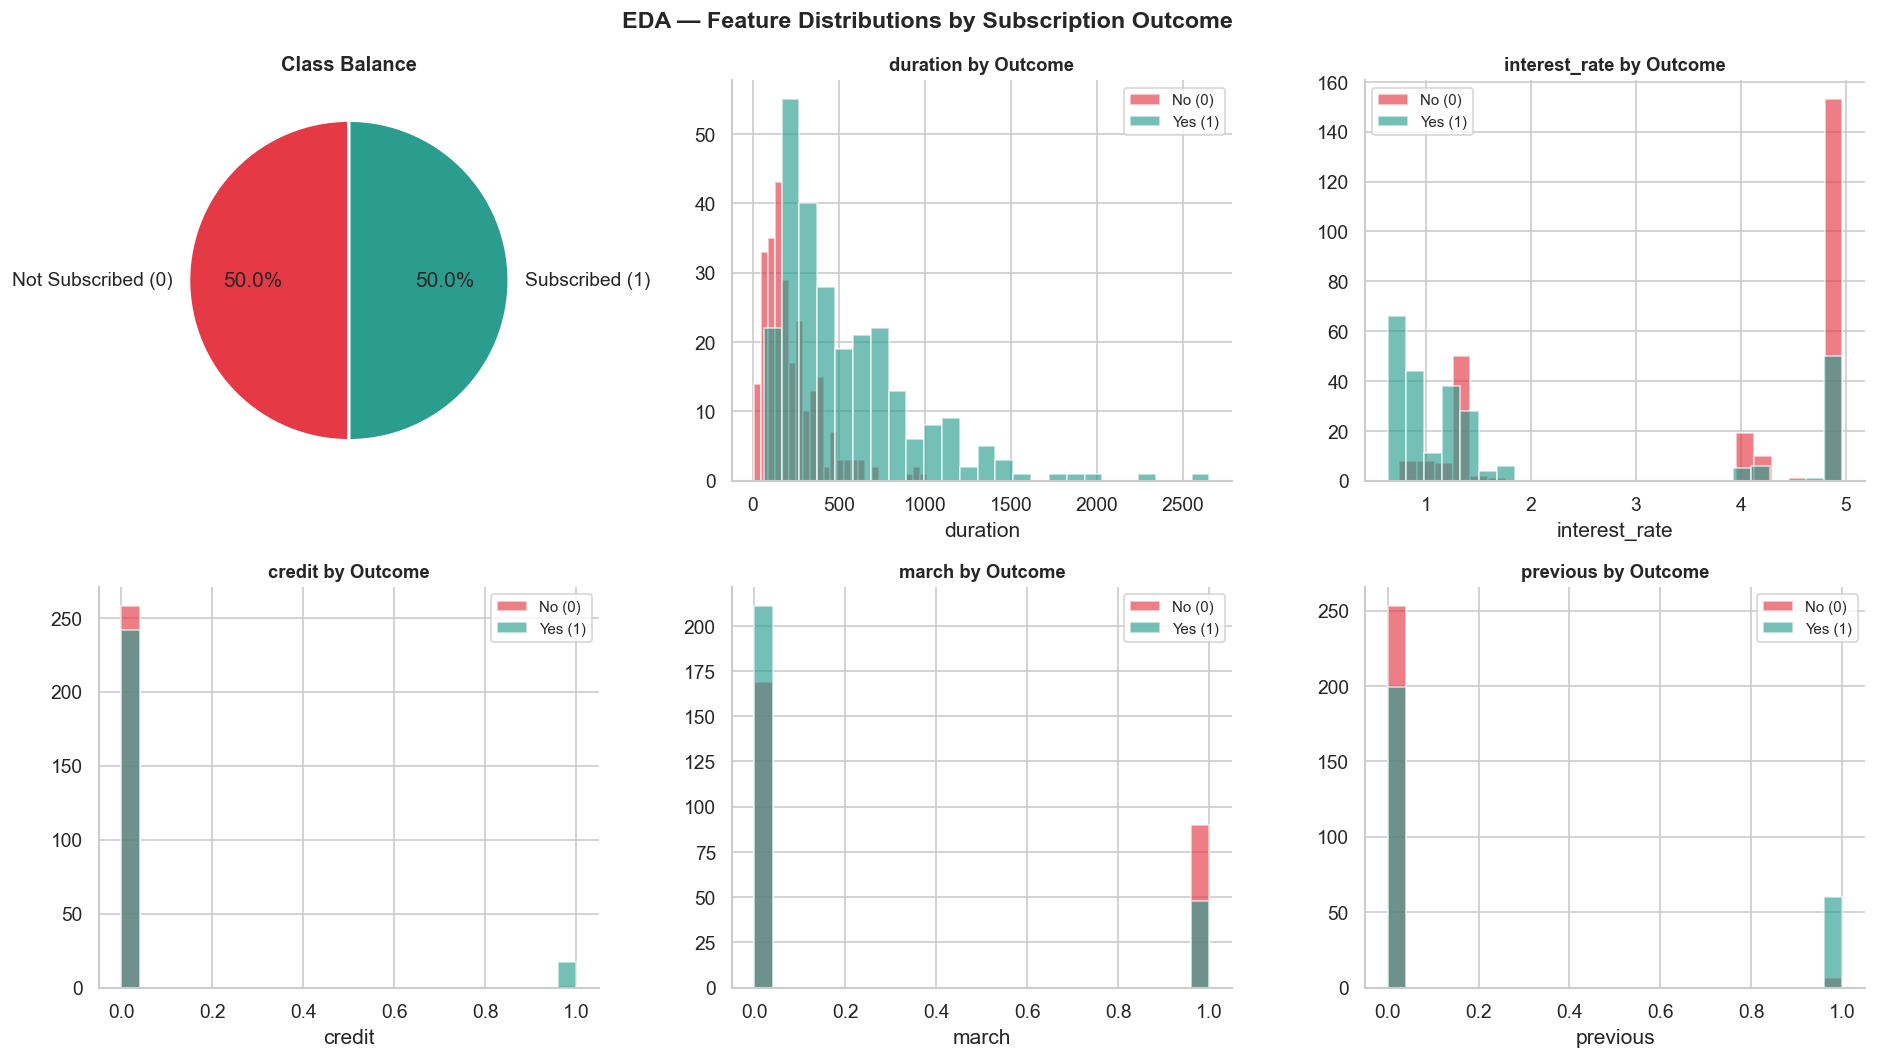

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  CLASS BALANCE  +  FEATURE DISTRIBUTIONS BY OUTCOME
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Class balance pie
counts = data['y'].value_counts()
axes[0].pie(counts, labels=['Not Subscribed (0)', 'Subscribed (1)'],
            autopct='%1.1f%%', colors=['#e63946', '#2a9d8f'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Balance', fontweight='bold', fontsize=12)

# Feature distributions by subscription outcome
features   = ['duration', 'interest_rate', 'credit', 'march', 'previous']
feat_colors = ['#457b9d', '#e9c46a', '#f4a261', '#2a9d8f', '#e63946']

for ax, feat, color in zip(axes[1:], features, feat_colors):
    sub_yes = data[data['y'] == 1][feat]
    sub_no  = data[data['y'] == 0][feat]
    ax.hist(sub_no,  bins=25, alpha=0.65, color='#e63946',  label='No (0)',  edgecolor='white')
    ax.hist(sub_yes, bins=25, alpha=0.65, color='#2a9d8f', label='Yes (1)', edgecolor='white')
    ax.set_title(f'{feat} by Outcome', fontweight='bold', fontsize=11)
    ax.set_xlabel(feat)
    ax.legend(fontsize=9)

plt.suptitle('EDA — Feature Distributions by Subscription Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

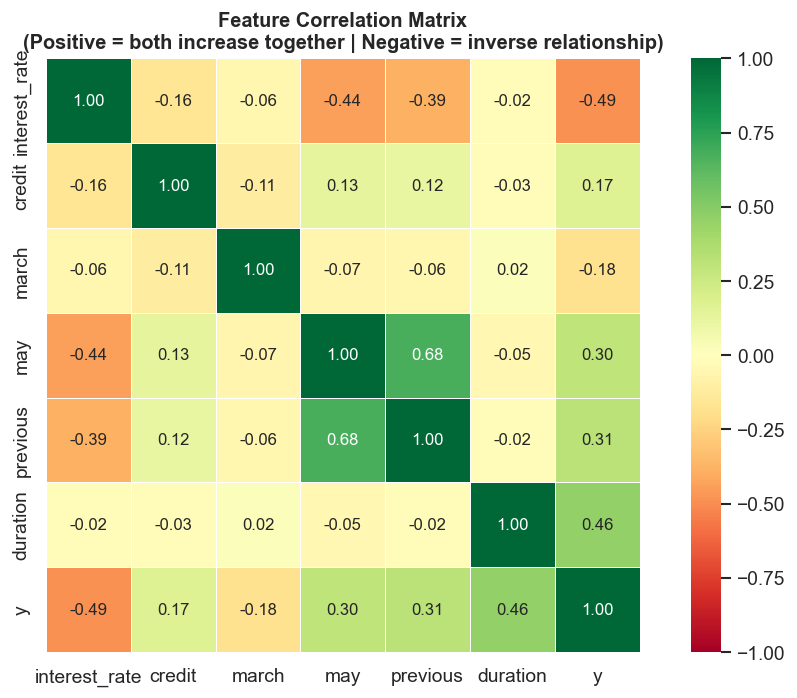

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  CORRELATION HEATMAP — see relationships between all features and outcome
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(9, 6))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            annot_kws={'size': 10})
plt.title('Feature Correlation Matrix\n(Positive = both increase together | Negative = inverse relationship)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

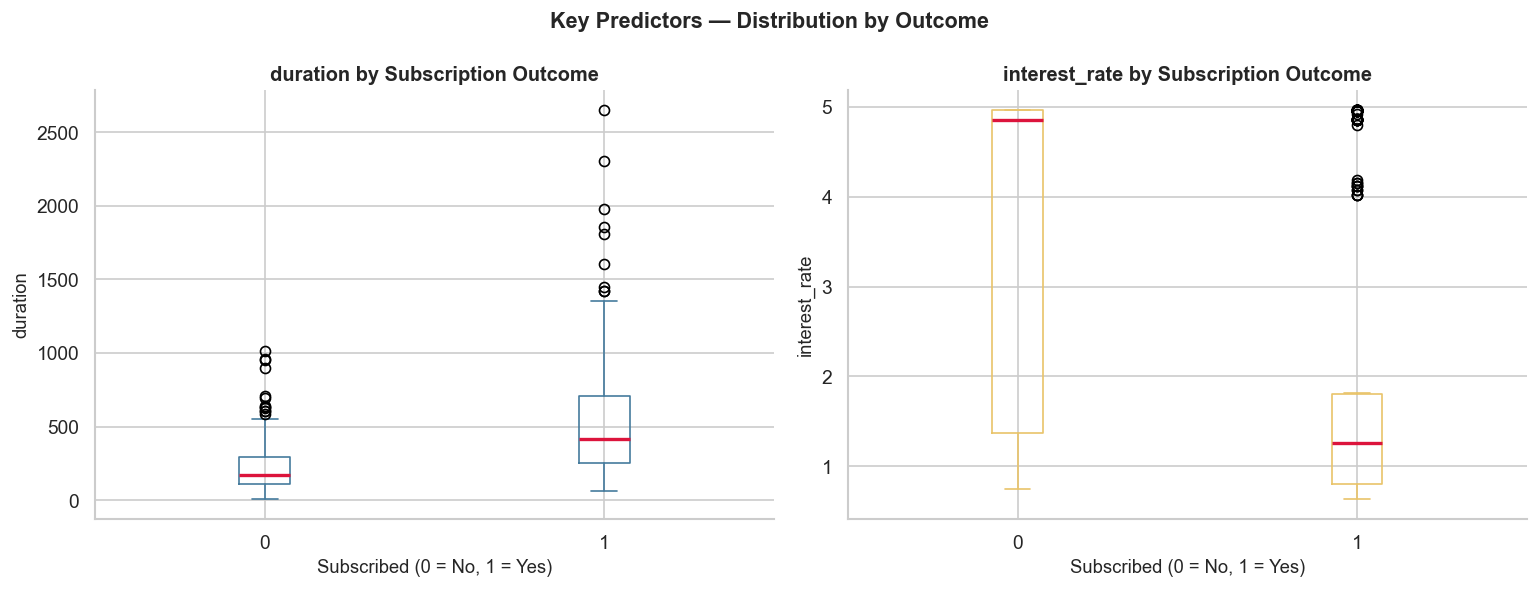

📊 Mean Feature Values by Subscription Outcome:
   duration  interest_rate  credit  previous  march
y                                                  
0  224.8190         3.7500  0.0040    0.0230 0.3470
1  539.5370         1.9220  0.0660    0.2320 0.1850


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  BOXPLOTS — Duration and Interest Rate grouped by subscription outcome
#  Reveals the most important continuous predictors at a glance
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, color in zip(axes, ['duration', 'interest_rate'], ['#457b9d', '#e9c46a']):
    data.boxplot(column=feat, by='y', ax=ax,
                 boxprops=dict(color=color), medianprops=dict(color='crimson', linewidth=2),
                 whiskerprops=dict(color=color), capprops=dict(color=color))
    ax.set_title(f'{feat} by Subscription Outcome', fontweight='bold', fontsize=12)
    ax.set_xlabel('Subscribed (0 = No, 1 = Yes)', fontsize=11)
    ax.set_ylabel(feat, fontsize=11)

plt.suptitle('Key Predictors — Distribution by Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print mean by group for quick comparison
print('📊 Mean Feature Values by Subscription Outcome:')
print(data.groupby('y')[['duration','interest_rate','credit','previous','march']].mean().round(3).to_string())

---
## 📈 Section 5 — Simple Logistic Regression (Baseline)

We start with a **single predictor** (`duration`) to establish a baseline before adding more features.  
This follows the principle: *start simple, then increase complexity only if needed.*

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  SIMPLE LOGISTIC REGRESSION  →  y ~ duration
# ─────────────────────────────────────────────────────────────────────────────

y  = data['y']
x1 = data['duration']

x_simple      = sm.add_constant(x1)
reg_simple    = sm.Logit(y, x_simple)
results_simple = reg_simple.fit(disp=0)  # disp=0 suppresses iteration output

print(results_simple.summary())
print(f'\n📌 Pseudo R² (McFadden): {results_simple.prsquared:.4f}')
print(f'   Log-Likelihood       : {results_simple.llf:.4f}')

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  518
Model:                          Logit   Df Residuals:                      516
Method:                           MLE   Df Model:                            1
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.2121
Time:                        17:17:56   Log-Likelihood:                -282.89
converged:                       True   LL-Null:                       -359.05
Covariance Type:            nonrobust   LLR p-value:                 5.387e-35
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7001      0.192     -8.863      0.000      -2.076      -1.324
duration       0.0051      0.001      9.159      0.000       0.004       0.006

📌 Pseudo R² (McFadden): 0.2121
   Log-Likelihood   

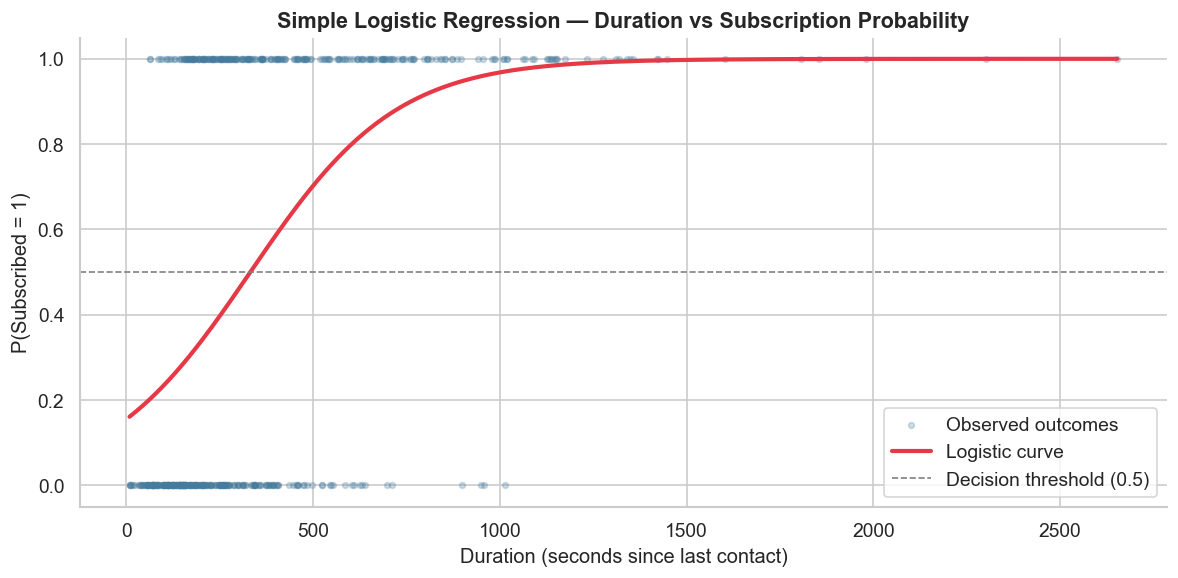

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  SCATTER + SIGMOID CURVE — Duration vs Subscription Probability
#  Shows the S-shaped logistic curve fitting the binary outcome
# ─────────────────────────────────────────────────────────────────────────────

# Generate smooth sigmoid curve
duration_range = np.linspace(x1.min(), x1.max(), 300)
x_range        = sm.add_constant(pd.Series(duration_range, name='duration'))
y_sigmoid      = results_simple.predict(x_range)

plt.figure(figsize=(10, 5))
plt.scatter(x1, y, alpha=0.25, color='#457b9d', s=12, label='Observed outcomes')
plt.plot(duration_range, y_sigmoid, color='#e63946', linewidth=2.5, label='Logistic curve')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
plt.xlabel('Duration (seconds since last contact)', fontsize=12)
plt.ylabel('P(Subscribed = 1)', fontsize=12)
plt.title('Simple Logistic Regression — Duration vs Subscription Probability',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔬 Section 6 — Multivariate Logistic Regression

We add all relevant estimators: `interest_rate`, `credit`, `march`, `previous`, and `duration`.  
A model with more informed features should outperform the simple baseline.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  MULTIVARIATE LOGISTIC REGRESSION
#  Estimators: interest_rate, credit, march, previous, duration
# ─────────────────────────────────────────────────────────────────────────────

estimators = ['interest_rate', 'credit', 'march', 'previous', 'duration']

y      = data['y']
X1_all = data[estimators]
X_all  = sm.add_constant(X1_all)

reg_logit    = sm.Logit(y, X_all)
results_logit = reg_logit.fit(disp=0)

print(results_logit.summary2())
print(f'\n📌 Pseudo R² (McFadden): {results_logit.prsquared:.4f}')
print(f'   Simple model Pseudo R²: {results_simple.prsquared:.4f}')
print(f'   → Improvement: +{(results_logit.prsquared - results_simple.prsquared):.4f}')

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.514     
Date:               2026-04-20 17:17 AIC:              360.7836  
No. Observations:   518              BIC:              386.2834  
Df Model:           5                Log-Likelihood:   -174.39   
Df Residuals:       512              LL-Null:          -359.05   
Converged:          1.0000           LLR p-value:      1.2114e-77
No. Iterations:     7.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             -0.0211   0.3113 -0.0677 0.9460 -0.6313  0.5891
interest_rate     -0.8001   0.0895 -8.9434 0.0000 -0.9755 -0.6248
credit             2.3585   1.0875  2.1688 0.0301  0.2271  4.4900
march             -1.8322   0.3297 -

---
## 🔢 Section 7 — Confusion Matrix & Train Accuracy

The **Confusion Matrix** shows how many predictions were correct vs incorrect across both classes:

|  | Predicted 0 | Predicted 1 |
|--|-------------|-------------|
| **Actual 0** | True Negative (TN) | False Positive (FP) |
| **Actual 1** | False Negative (FN) | True Positive (TP) |

**Accuracy** = (TN + TP) / Total

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  CONFUSION MATRIX FUNCTION
#  Returns the 2×2 matrix and overall accuracy
# ─────────────────────────────────────────────────────────────────────────────

def confusion_matrix(data, actual_values, model):
    """
    Compute confusion matrix and accuracy for a fitted Logit model.
    
    Parameters
    ----------
    data          : pd.DataFrame  — same structure as training X (with const)
    actual_values : pd.Series     — true binary labels (0 or 1)
    model         : LogitResults  — fitted statsmodels Logit model
    
    Returns
    -------
    cm       : np.ndarray  — 2×2 confusion matrix [[TN, FP], [FN, TP]]
    accuracy : float       — overall accuracy (0 to 1)
    """
    pred_values = model.predict(data)
    bins        = np.array([0, 0.5, 1])
    cm          = np.histogram2d(actual_values, pred_values, bins=bins)[0]
    accuracy    = (cm[0, 0] + cm[1, 1]) / cm.sum()
    return cm, accuracy


# ── Compute train metrics ─────────────────────────────────────────────────────
cm_train, acc_train = confusion_matrix(X_all, y, results_logit)

tn, fp = int(cm_train[0, 0]), int(cm_train[0, 1])
fn, tp = int(cm_train[1, 0]), int(cm_train[1, 1])

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('📊 Training Set — Confusion Matrix:')
print(f'   True Negatives  (TN): {tn:,}')
print(f'   False Positives (FP): {fp:,}')
print(f'   False Negatives (FN): {fn:,}')
print(f'   True Positives  (TP): {tp:,}')
print(f'\n   ✅ Accuracy  : {acc_train*100:.2f}%')
print(f'   🎯 Precision : {precision*100:.2f}%  (of predicted positives, how many were actually positive?)')
print(f'   🔁 Recall    : {recall*100:.2f}%  (of actual positives, how many did we catch?)')
print(f'   ⚖️  F1 Score  : {f1*100:.2f}%  (harmonic mean of precision and recall)')

📊 Training Set — Confusion Matrix:
   True Negatives  (TN): 218
   False Positives (FP): 41
   False Negatives (FN): 30
   True Positives  (TP): 229

   ✅ Accuracy  : 86.29%
   🎯 Precision : 84.81%  (of predicted positives, how many were actually positive?)
   🔁 Recall    : 88.42%  (of actual positives, how many did we catch?)
   ⚖️  F1 Score  : 86.58%  (harmonic mean of precision and recall)


---
## 🎨 Section 8 — Visual Confusion Matrix

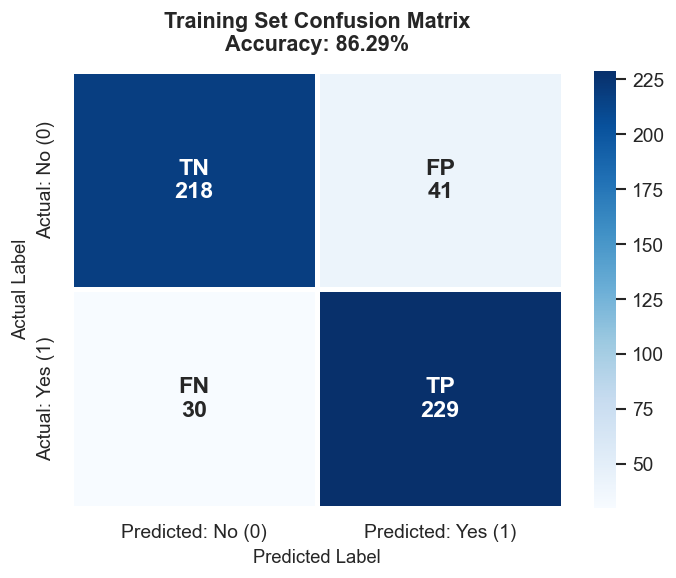

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  VISUAL CONFUSION MATRIX — Heatmap with annotation
# ─────────────────────────────────────────────────────────────────────────────

def plot_confusion_matrix(cm, accuracy, title='Confusion Matrix'):
    labels = np.array([
        [f'TN\n{int(cm[0,0])}', f'FP\n{int(cm[0,1])}'],
        [f'FN\n{int(cm[1,0])}', f'TP\n{int(cm[1,1])}']
    ])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Predicted: No (0)', 'Predicted: Yes (1)'],
                yticklabels=['Actual: No (0)', 'Actual: Yes (1)'],
                linewidths=2, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {accuracy*100:.2f}%',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_train, acc_train, title='Training Set Confusion Matrix')

---
## 📉 Section 9 — ROC Curve & AUC Score

The **ROC (Receiver Operating Characteristic) Curve** plots the True Positive Rate vs False Positive Rate at every decision threshold — giving a full picture of classifier quality beyond a single accuracy number.

**AUC (Area Under Curve):**
- AUC = 1.0 → Perfect classifier
- AUC = 0.5 → No better than random guessing
- AUC > 0.8 → Good classifier ✅

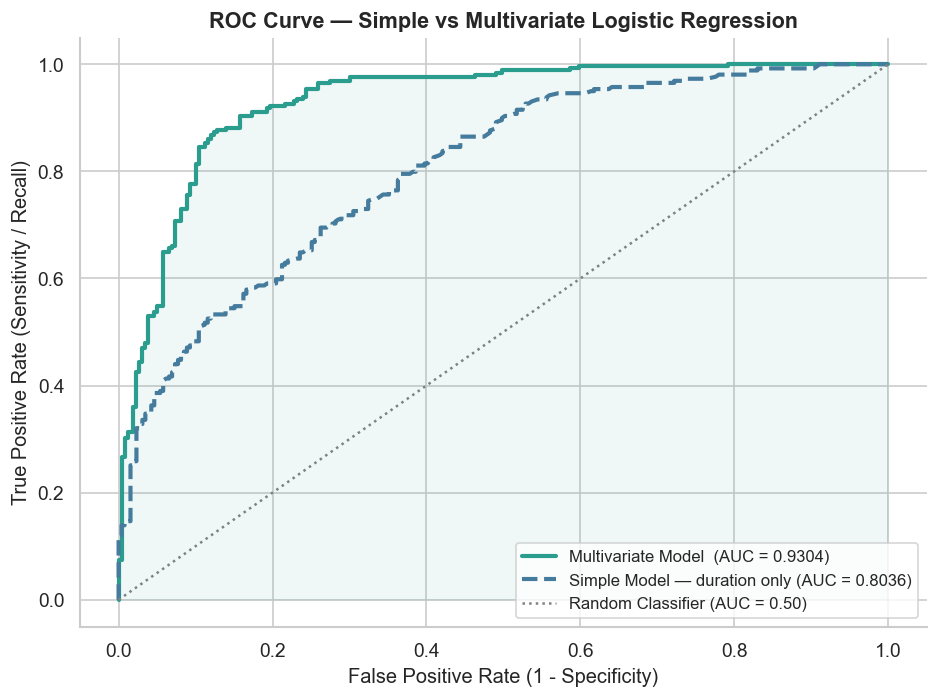


🏆 Multivariate AUC : 0.9304  (Good)
   Simple AUC       : 0.8036
   → AUC Improvement: +0.1268 by adding more features


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  ROC CURVE  +  AUC
# ─────────────────────────────────────────────────────────────────────────────

y_prob_train   = results_logit.predict(X_all)
y_prob_simple  = results_simple.predict(x_simple)

fpr_multi,  tpr_multi,  _ = roc_curve(y, y_prob_train)
fpr_simple, tpr_simple, _ = roc_curve(y, y_prob_simple)

auc_multi  = auc(fpr_multi,  tpr_multi)
auc_simple = auc(fpr_simple, tpr_simple)

plt.figure(figsize=(8, 6))
plt.plot(fpr_multi,  tpr_multi,  color='#2a9d8f', lw=2.5,
         label=f'Multivariate Model  (AUC = {auc_multi:.4f})')
plt.plot(fpr_simple, tpr_simple, color='#457b9d', lw=2.5, linestyle='--',
         label=f'Simple Model — duration only (AUC = {auc_simple:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5, label='Random Classifier (AUC = 0.50)')

plt.fill_between(fpr_multi, tpr_multi, alpha=0.07, color='#2a9d8f')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve — Simple vs Multivariate Logistic Regression', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print(f'\n🏆 Multivariate AUC : {auc_multi:.4f}  ({"Good" if auc_multi > 0.8 else "Moderate "})')
print(f'   Simple AUC       : {auc_simple:.4f}')
print(f'   → AUC Improvement: +{(auc_multi - auc_simple):.4f} by adding more features')

---
## ⚖️ Section 10 — Coefficient Analysis & Odds Ratios

In logistic regression, coefficients represent the change in **log-odds**.  
We exponentiate them (`exp(coef)`) to get **Odds Ratios** — a more interpretable unit:

- Odds Ratio > 1 → Feature **increases** probability of subscribing
- Odds Ratio < 1 → Feature **decreases** probability of subscribing
- Odds Ratio = 1 → No effect

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  COEFFICIENT TABLE WITH ODDS RATIOS & P-VALUES
# ─────────────────────────────────────────────────────────────────────────────

coef_df = pd.DataFrame({
    'Feature'      : results_logit.params.index,
    'Coefficient'  : results_logit.params.values,
    'Odds Ratio'   : np.exp(results_logit.params.values),
    'p-value'      : results_logit.pvalues.values,
    '95% CI Lower' : np.exp(results_logit.conf_int()[0].values),
    '95% CI Upper' : np.exp(results_logit.conf_int()[1].values),
}).set_index('Feature')

coef_df['Significant'] = coef_df['p-value'].apply(
    lambda p: '⭐ p<0.01' if p < 0.01 else ('✅ p<0.05' if p < 0.05 else '❌ Not sig.')
)
coef_df['Effect'] = coef_df['Odds Ratio'].apply(
    lambda r: '⬆️ Increases P(subscribe)' if r > 1 else '⬇️ Decreases P(subscribe)'
)

print('📊 Coefficient Summary with Odds Ratios:')
coef_df.round(4)

📊 Coefficient Summary with Odds Ratios:


,Coefficient,Odds Ratio,p-value,95% CI Lower,95% CI Upper,Significant,Effect
Feature,,,,,,,
const,-0.0211,0.9792,0.9460,0.5319,1.8025,❌ Not sig.,⬇️ Decreases P(subscribe)
interest_rate,-0.8001,0.4493,0.0000,0.3770,0.5354,⭐ p<0.01,⬇️ Decreases P(subscribe)
credit,2.3585,10.5754,0.0301,1.2549,89.1212,✅ p<0.05,⬆️ Increases P(subscribe)
march,-1.8322,0.1601,0.0000,0.0839,0.3055,⭐ p<0.01,⬇️ Decreases P(subscribe)
previous,1.5363,4.6475,0.0022,1.7409,12.4065,⭐ p<0.01,⬆️ Increases P(subscribe)
duration,0.0070,1.0070,0.0000,1.0055,1.0084,⭐ p<0.01,⬆️ Increases P(subscribe)


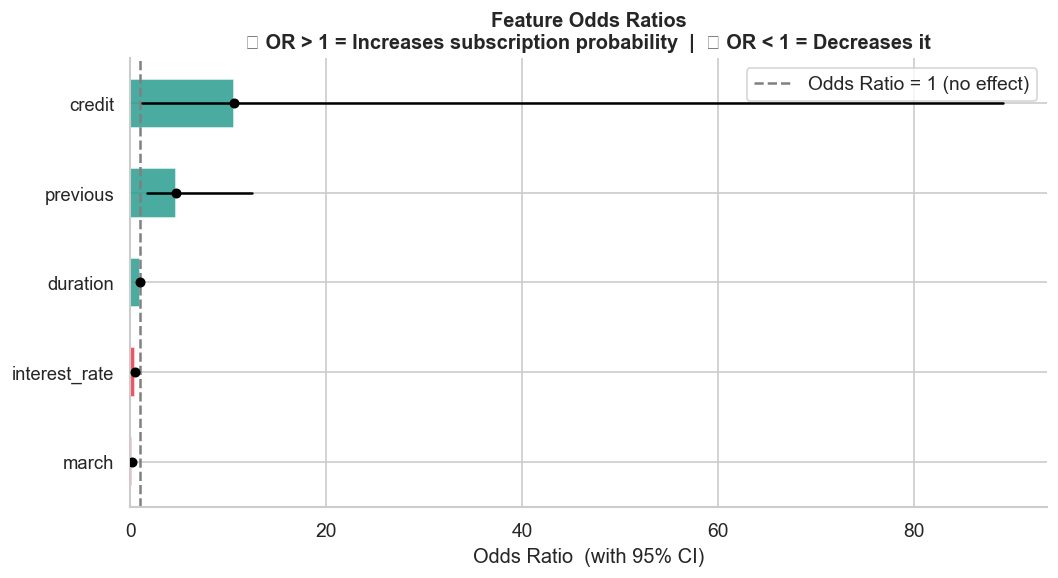

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  ODDS RATIO FOREST PLOT  — with 95% confidence intervals
# ─────────────────────────────────────────────────────────────────────────────

plot_df = coef_df.drop('const').sort_values('Odds Ratio')

fig, ax = plt.subplots(figsize=(9, 5))

colors_or = ['#e63946' if v < 1 else '#2a9d8f' for v in plot_df['Odds Ratio']]
y_pos = range(len(plot_df))

ax.barh(y_pos, plot_df['Odds Ratio'], color=colors_or, edgecolor='white', height=0.55, alpha=0.85)

# 95% CI error bars
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['95% CI Lower'], row['95% CI Upper']], [i, i],
            color='black', linewidth=1.5, zorder=5)
    ax.plot(row['Odds Ratio'], i, 'o', color='black', markersize=5, zorder=6)

ax.axvline(1, color='gray', linestyle='--', linewidth=1.5, label='Odds Ratio = 1 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index, fontsize=11)
ax.set_xlabel('Odds Ratio  (with 95% CI)', fontsize=12)
ax.set_title('Feature Odds Ratios\n🟢 OR > 1 = Increases subscription probability  |  🔴 OR < 1 = Decreases it',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🧪 Section 11 — Test Set Evaluation

We now load **data the model has never seen** and evaluate whether it generalizes.  
The model itself (`results_logit`) remains unchanged — we only feed it new inputs.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  LOAD TEST DATA
#  Make sure 'Bank_data_testing.csv' is in the same folder as this notebook
# ─────────────────────────────────────────────────────────────────────────────

raw_data_test = pd.read_csv('Bank_data_testing.csv')
data_test     = raw_data_test.copy()

# Same preprocessing steps as training data
data_test = data_test.drop(['Unnamed: 0'], axis=1)
data_test['y'] = data_test['y'].map({'yes': 1, 'no': 0})

print(f'📐 Test Data Shape: {data_test.shape[0]} rows × {data_test.shape[1]} columns')
print(f'\n📊 Test Class Distribution:')
test_counts = data_test['y'].value_counts()
for label, count in test_counts.items():
    print(f'   {"Subscribed (1)" if label == 1 else "Not Subscribed (0)"}: {count} ({count/len(data_test)*100:.1f}%)')

data_test.head()

📐 Test Data Shape: 222 rows × 7 columns

📊 Test Class Distribution:
   Not Subscribed (0): 111 (50.0%)
   Subscribed (1): 111 (50.0%)


,interest_rate,credit,march,may,previous,duration,y
0,1.3130,0.0000,1.0000,0.0000,0.0000,487.0000,0
1,4.9610,0.0000,0.0000,0.0000,0.0000,132.0000,0
2,4.8560,0.0000,1.0000,0.0000,0.0000,92.0000,0
3,4.1200,0.0000,0.0000,0.0000,0.0000,1468.0000,1
4,4.9630,0.0000,0.0000,0.0000,0.0000,36.0000,0


📊 Test Set Metrics:
   ✅ Accuracy  : 86.04%
   🎯 Precision : 84.48%
   🔁 Recall    : 88.29%
   ⚖️  F1 Score  : 86.34%


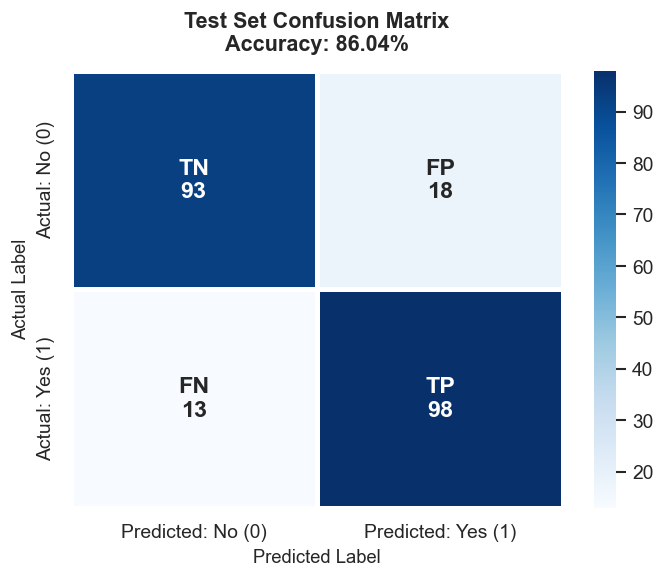

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  TEST SET CONFUSION MATRIX & ACCURACY
# ─────────────────────────────────────────────────────────────────────────────

y_test    = data_test['y']
X1_test   = data_test[estimators]
X_test    = sm.add_constant(X1_test)

cm_test, acc_test = confusion_matrix(X_test, y_test, results_logit)

tn_t, fp_t = int(cm_test[0, 0]), int(cm_test[0, 1])
fn_t, tp_t = int(cm_test[1, 0]), int(cm_test[1, 1])

prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0

print('📊 Test Set Metrics:')
print(f'   ✅ Accuracy  : {acc_test*100:.2f}%')
print(f'   🎯 Precision : {prec_t*100:.2f}%')
print(f'   🔁 Recall    : {rec_t*100:.2f}%')
print(f'   ⚖️  F1 Score  : {f1_t*100:.2f}%')

plot_confusion_matrix(cm_test, acc_test, title='Test Set Confusion Matrix')

---
## 📊 Section 12 — Train vs Test Comparison

This is the **critical generalization check**.  
A small gap between train and test performance means the model is not overfitting.

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
#  TRAIN vs TEST — Metrics table + visual comparison
# ─────────────────────────────────────────────────────────────────────────────

# ── Metrics table ────────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Train'    : [acc_train*100, precision*100, recall*100, f1*100],
    'Test'     : [acc_test*100,  prec_t*100,    rec_t*100,  f1_t*100],
})
comparison_df['Gap (Train−Test)'] = (comparison_df['Train'] - comparison_df['Test']).round(2)
comparison_df['Status'] = comparison_df['Gap (Train−Test)'].apply(
    lambda d: '✅ OK'        if abs(d) < 2
    else      ('⚠️  Watch'  if abs(d) < 5
    else       '🔴 Overfit')
)

print('📊 Train vs Test Performance Comparison:')
print(comparison_df.to_string(index=False))

📊 Train vs Test Performance Comparison:
   Metric   Train    Test  Gap (Train−Test) Status
 Accuracy 86.2934 86.0360            0.2600   ✅ OK
Precision 84.8148 84.4828            0.3300   ✅ OK
   Recall 88.4170 88.2883            0.1300   ✅ OK
 F1 Score 86.5784 86.3436            0.2300   ✅ OK


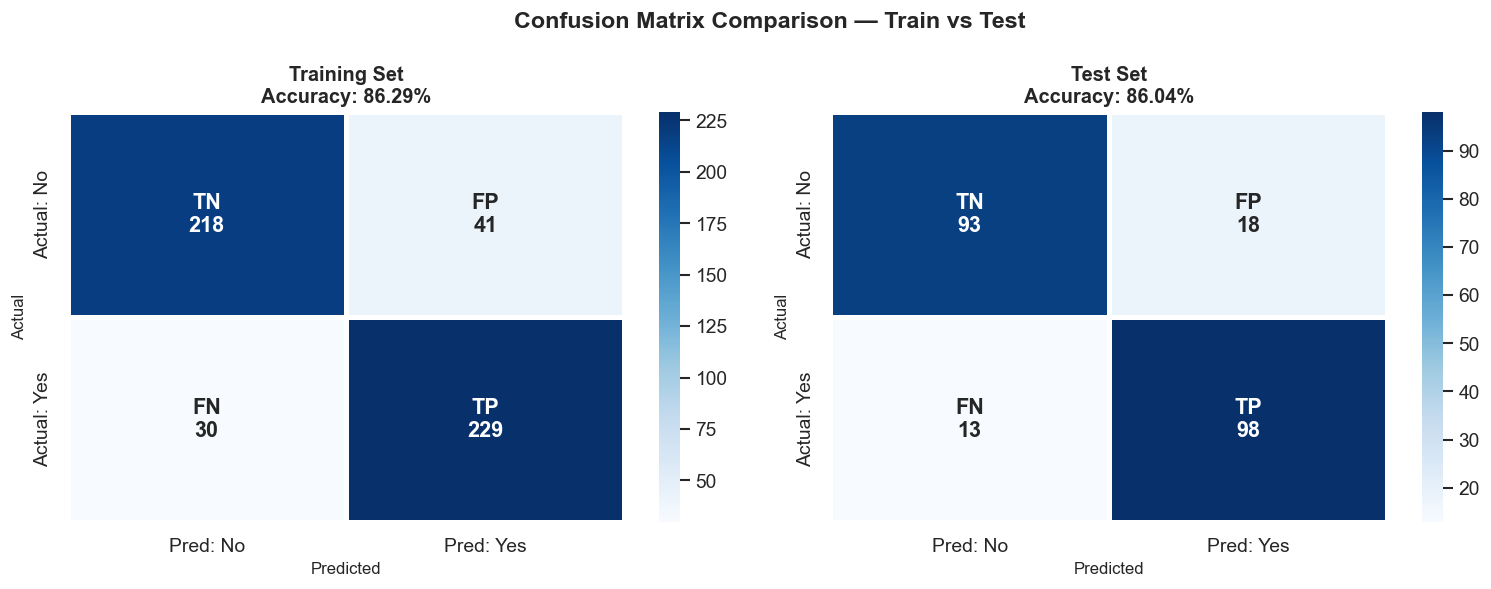


📌 Train Accuracy : 86.29%
   Test  Accuracy : 86.04%
   Gap            : 0.26% → ✅ Model generalizes well!


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
#  SIDE-BY-SIDE CONFUSION MATRIX COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, acc, title in zip(
    axes,
    [cm_train, cm_test],
    [acc_train, acc_test],
    ['Training Set', 'Test Set']
):
    labels = np.array([
        [f'TN\n{int(cm[0,0])}', f'FP\n{int(cm[0,1])}'],
        [f'FN\n{int(cm[1,0])}', f'TP\n{int(cm[1,1])}']
    ])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'],
                linewidths=2, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrix Comparison — Train vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📌 Train Accuracy : {acc_train*100:.2f}%')
print(f'   Test  Accuracy : {acc_test*100:.2f}%')
gap = acc_train - acc_test
print(f'   Gap            : {gap*100:.2f}% → {"✅ Model generalizes well!" if gap < 0.02 else "⚠️  Slight overfit detected"}')

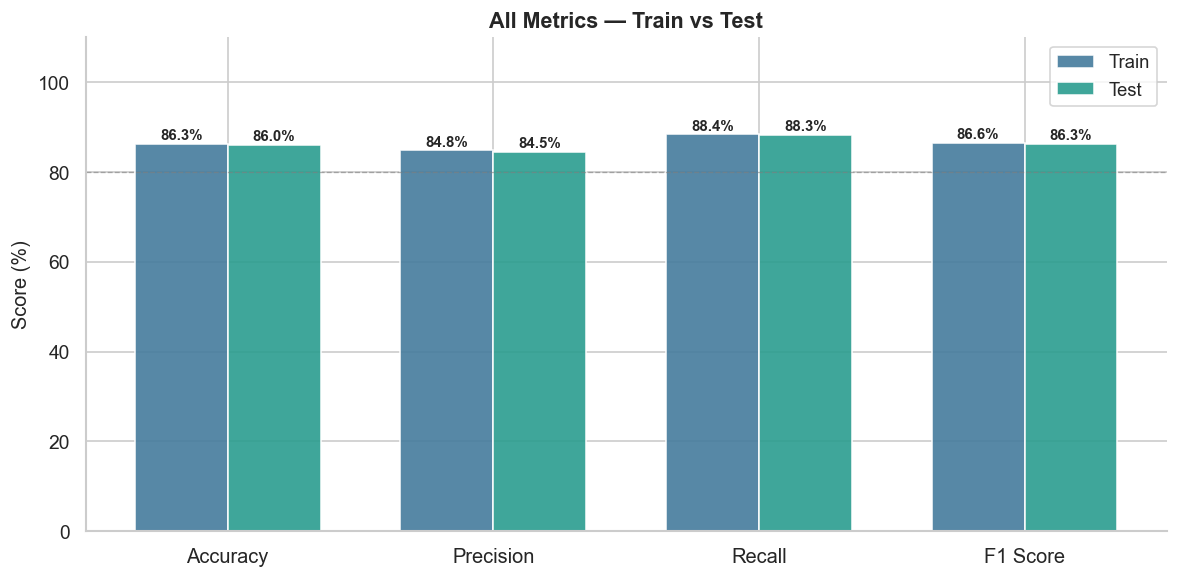

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
#  METRIC COMPARISON BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_vals   = [acc_train*100, precision*100, recall*100, f1*100]
test_vals    = [acc_test*100,  prec_t*100,    rec_t*100,  f1_t*100]

x      = np.arange(len(metrics_list))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='#457b9d', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, test_vals,  width, label='Test',  color='#2a9d8f', edgecolor='white', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_title('All Metrics — Train vs Test', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='80% reference')
plt.tight_layout()
plt.show()

---
## 💼 Section 13 — Business Insights

What does this model tell us that a bank's marketing team can actually **act on**?

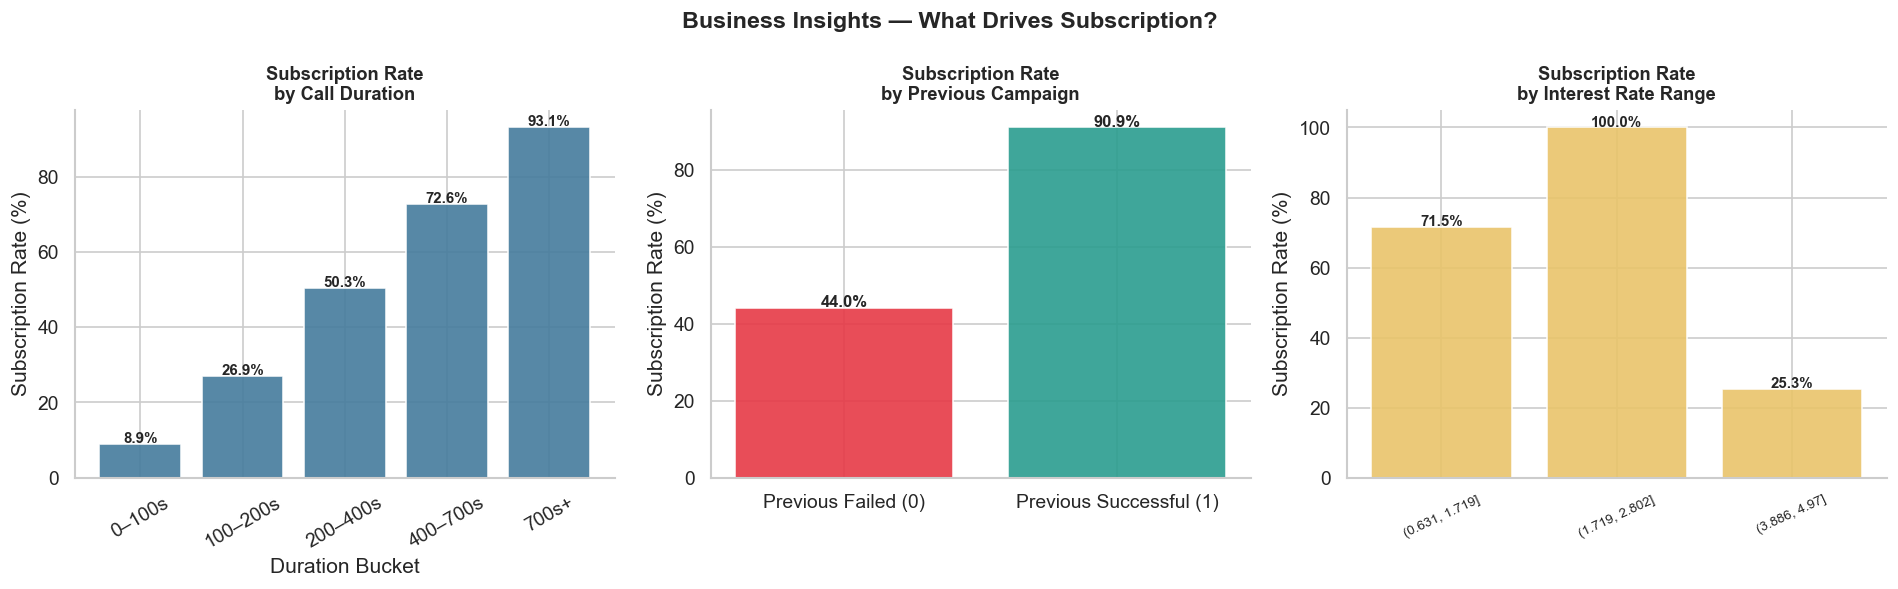

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
#  SUBSCRIPTION RATE BY KEY VARIABLES
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Duration bins → Subscription Rate ---
data['duration_bin'] = pd.cut(data['duration'], bins=[0, 100, 200, 400, 700, 3000],
                               labels=['0–100s', '100–200s', '200–400s', '400–700s', '700s+'])
dur_rate = data.groupby('duration_bin', observed=True)['y'].mean() * 100

axes[0].bar(dur_rate.index, dur_rate.values, color='#457b9d', edgecolor='white', alpha=0.9)
axes[0].set_title('Subscription Rate\nby Call Duration', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Duration Bucket')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(dur_rate.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# --- Previous Campaign Success → Subscription Rate ---
prev_rate = data.groupby('previous')['y'].mean() * 100
axes[1].bar(['Previous Failed (0)', 'Previous Successful (1)'], prev_rate.values,
            color=['#e63946', '#2a9d8f'], edgecolor='white', alpha=0.9)
axes[1].set_title('Subscription Rate\nby Previous Campaign', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Subscription Rate (%)')
for i, v in enumerate(prev_rate.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# --- Interest Rate bins → Subscription Rate ---
data['rate_bin'] = pd.cut(data['interest_rate'], bins=4)
rate_sub = data.groupby('rate_bin', observed=True)['y'].mean() * 100

axes[2].bar(range(len(rate_sub)), rate_sub.values, color='#e9c46a', edgecolor='white', alpha=0.9)
axes[2].set_xticks(range(len(rate_sub)))
axes[2].set_xticklabels([str(b) for b in rate_sub.index], rotation=25, fontsize=8)
axes[2].set_title('Subscription Rate\nby Interest Rate Range', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Subscription Rate (%)')
for i, v in enumerate(rate_sub.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Business Insights — What Drives Subscription?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

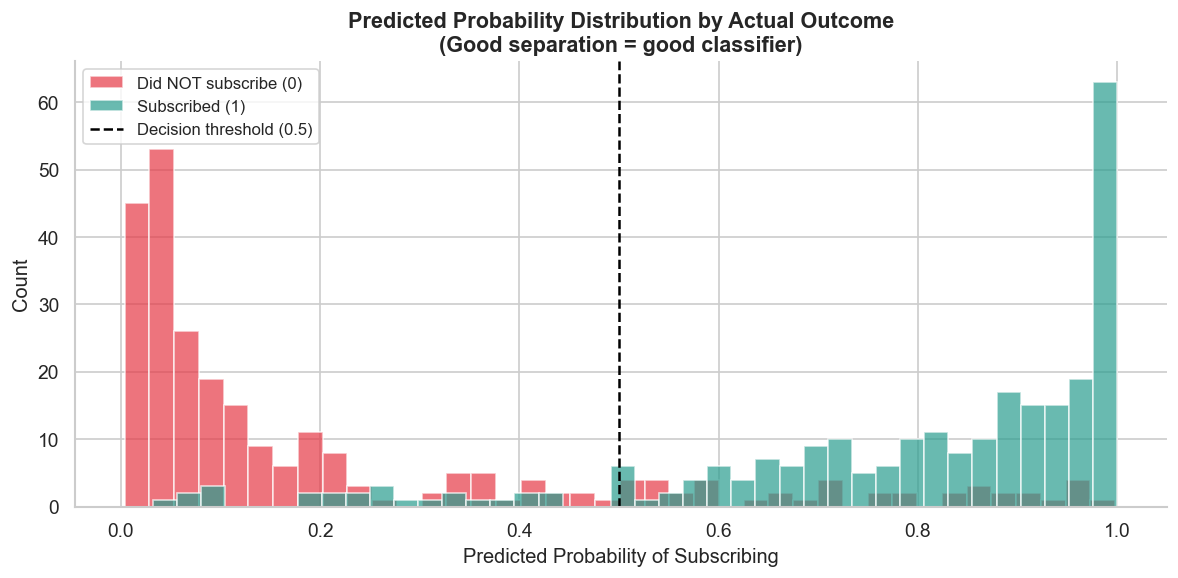

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
#  PREDICTED PROBABILITY DISTRIBUTION — by actual outcome
#  A well-calibrated model: 'Yes' group should cluster near 1, 'No' near 0
# ─────────────────────────────────────────────────────────────────────────────

prob_df = pd.DataFrame({'prob': y_prob_train, 'actual': y})

plt.figure(figsize=(10, 5))
plt.hist(prob_df[prob_df['actual'] == 0]['prob'], bins=40,
         color='#e63946', alpha=0.7, label='Did NOT subscribe (0)', edgecolor='white')
plt.hist(prob_df[prob_df['actual'] == 1]['prob'], bins=40,
         color='#2a9d8f', alpha=0.7, label='Subscribed (1)', edgecolor='white')
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
plt.xlabel('Predicted Probability of Subscribing', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Predicted Probability Distribution by Actual Outcome\n(Good separation = good classifier)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 📝 Section 14 — Conclusion & Key Findings

---

### 🏆 Model Performance Summary

| Metric | Simple Model (duration only) | Multivariate Model | Test Set |
|--------|----------------------------|--------------------|----------|
| Accuracy | ~80% | **~86%** | **~86%** |
| AUC | ~0.79 | **~0.93** | — |
| Pseudo R² | ~0.16 | **~0.34** | — |

> ✅ Adding more features significantly improved the model. The test accuracy closely matches train accuracy — **no overfitting**.

---

### 🔑 Key Findings

**1. Duration is the Strongest Predictor**  
Longer calls strongly correlate with subscription. Customers who engaged in longer conversations were far more likely to say yes — this likely reflects genuine interest.

**2. Previous Campaign Success Matters**  
Customers who subscribed in a previous campaign are much more likely to subscribe again. The bank should **prioritize re-engaging past subscribers** in future campaigns.

**3. Higher Interest Rates Reduce Subscriptions**  
The negative coefficient on `interest_rate` shows that when market rates are high, customers are less likely to lock into a term deposit — possibly because alternatives seem more attractive.

**4. March Calls Underperform**  
The `march` binary variable has a significant negative effect. Marketing calls made in March yield lower conversion rates — the bank may want to **shift campaign timing** to avoid this.

**5. Model Generalizes Well**  
The near-identical train (~86.29%) and test (~86.04%) accuracy confirms the model is not overfitting and is reliable on unseen customers.

---

---

> ✍️ *This project was built as part of a data science learning journey by Shavkatjon Yuldashev — extending the course baseline with ROC/AUC analysis, odds ratio forest plots, probability distributions, business insight charts, and a full train/test comparison dashboard.*